# Koopman MPC (debuggable)

Minimal, step-by-step acados setup using the saved EDMD Koopman model (`test_model.npz`).
The cost is quadratic on the lifted state and control, and the only constraint (besides optional box bounds) is the lifted linear dynamics.

In [1]:
import numpy as np
from casadi import MX
from acados_template import AcadosOcp, AcadosOcpSolver, AcadosModel
from pathlib import Path

# Try to import the EDMD lift used in training (polynomial 1D lift)
try:
    from simulation.edmd.edmd_runner import lift_1d
except Exception:
    lift_1d = None

# Path to the saved Koopman model (A, B, and optional metadata)
model_path = Path("saved_models_koopman/wrench_model.npz").resolve()
print(f"Loading Koopman model from: {model_path}")
data = np.load(model_path, allow_pickle=True)
A = np.asarray(data["A"], dtype=float)
B = np.asarray(data["B"], dtype=float)
meta = data["meta"].item() if "meta" in data.files and np.asarray(data["meta"]).size == 1 else {}

# Determine p_max from meta if present; otherwise infer from A dimension: nx = 24 + 9*p_max
if isinstance(meta, dict) and "p_max" in meta:
    p_max = int(meta["p_max"])
else:
    nxA = A.shape[0]
    pm = (nxA - 24) / 9
    if abs(pm - round(pm)) > 1e-6 or pm < 0:
        raise ValueError(f"Cannot infer p_max from A.shape[0]={nxA}")
    p_max = int(round(pm))
expected_nx = 24 + 9 * p_max
if A.shape[0] != expected_nx:
    raise ValueError(
        f"Inconsistent Koopman model dims: A is {A.shape[0]}x{A.shape[1]}, expected nx={expected_nx} for p_max={p_max}"
    )

# Lift function matching training; fallback to identity only if Koopman model is 12x12

def lift_fn(x):
    x = np.asarray(x, float)
    if lift_1d is None:
        if A.shape[0] != 12:
            raise ImportError("lift_1d not found and Koopman model not 12D; add simulation/edmd to PYTHONPATH or provide lift_1d.")
        return x
    return lift_1d(x, p_max)

print("A shape:", A.shape, "B shape:", B.shape, "meta keys:", list(meta) if isinstance(meta, dict) else meta, "p_max:", p_max)


Loading Koopman model from: /home/sriramk/quad_koopman_mpc/simulation/edmd/saved_models_koopman/wrench_model.npz
A shape: (69, 69) B shape: (69, 6) meta keys: ['p_max', 'l2_reg', 'input_mode'] p_max: 5


In [2]:
# Basic dimensions and weights
nx = A.shape[0]
nu = B.shape[1]
N = 10               # horizon
# If the model stored a sample time, use it; otherwise fall back to 20 ms
if isinstance(meta, dict) and 'dt' in meta:
    dt = float(meta['dt'])
else:
    dt = 0.02

# Koopman lift ordering: [pos(3), lin_vel(3), vec(R)(9), omega(3), psi_bar...].
# Track p, v, vec(R), and w. leave psi_bar unweighted.
Q = np.zeros((nx, nx))
# position
Q[0:3, 0:3] = [1.0, 1.0, 1000.0]
# linear velocity
Q[3:6, 3:6] = [100.0, 100.0, 1000.0]
# rotation matrix block vec(R)
if nx >= 15:
    Q[6:15, 6:15] = [10.0, 10.0, 0, 10.0, 10.0, 0, 0, 0, 10.0]
# omega block: wx, wy, wz
if nx >= 24:
    Q[15:18, 15:18] = [0.0, 0.0, 10.0]
# psi_bar left zero
if nx >= 18:
    Q[18:21, 18:21] = 0.0  
         
# Control cost: weight first 3 (forces) and last 3 (torques); others zero
R = np.zeros((nu, nu))
R[0, 0] = 1e-2
R[1, 1] = 1e-2
R[2, 2] = 5e-3
R[3, 3] = 1e-2
R[4, 4] = 1e-2
R[5, 5] = 5e-3

print(f"nx={nx}, nu={nu}, horizon={N}, dt={dt}")


nx=69, nu=6, horizon=10, dt=0.02


In [3]:
# Reference: smooth ramp to commanded base linear & angular velocity, positions/yaw anchored to zero, z fixed
vx_cmd, vy_cmd = 0.3, 0.1       # target m/s
yaw_rate_cmd = 0.2              # target rad/s
z_ref_height = 0.1              # m
a_max = 1.0                     # max lin accel magnitude (per axis) m/s^2
yaw_acc_max = 1.0               # max yaw acceleration rad/s^2

x_ref_phys = np.zeros((N + 1, 12))
v_ref = np.zeros((N + 1, 3))
w_ref = np.zeros((N + 1, 3))

for k in range(N):
    # smooth velocity ramp
    dv = np.array([vx_cmd, vy_cmd, 0.0]) - v_ref[k]
    dv = np.clip(dv, -a_max * dt, a_max * dt)
    v_ref[k + 1] = v_ref[k] + dv

    dyaw = yaw_rate_cmd - w_ref[k, 2]
    dyaw = np.clip(dyaw, -yaw_acc_max * dt, yaw_acc_max * dt)
    w_ref[k + 1, 2] = w_ref[k, 2] + dyaw

    # anchor position and yaw to zero; set z
    x_ref_phys[k + 1, 0:3] = [0.0, 0.0, z_ref_height]
    x_ref_phys[k + 1, 5] = 0.0

# assign velocities and w into ref state
x_ref_phys[:, 6:9] = v_ref
x_ref_phys[:, 11] = w_ref[:, 2]

# Lift references to Koopman space
x_ref = np.zeros((N + 1, A.shape[0]))
for k in range(N + 1):
    zk = np.asarray(lift_fn(x_ref_phys[k]), float).reshape(-1)
    if zk.size != A.shape[0]:
        raise ValueError(f"Lifted ref dim mismatch: got {zk.size}, expected {A.shape[0]}")
    x_ref[k] = zk

# Initial physical state and lifted state
x0_phys = np.zeros(12)
x0_phys[2] = z_ref_height
x0 = np.asarray(lift_fn(x0_phys), float).reshape(-1)
if x0.size != A.shape[0]:
    raise ValueError(f"Lifted x0 dim mismatch: got {x0.size}, expected {A.shape[0]}")

# Control reference: net wrench with fz = m*g, others zero
mass_ref = float(meta.get("mass", 12.019)) if isinstance(meta, dict) else 12.019
g_ref = abs(float(meta.get("g", 9.81))) if isinstance(meta, dict) else 9.81
u_ref = np.zeros((N, B.shape[1]))
if u_ref.shape[1] >= 3:
    u_ref[:, 2] = mass_ref * g_ref

print("Reference built: final physical pose", x_ref_phys[-1, :6])


Reference built: final physical pose [0.  0.  0.1 0.  0.  0. ]


In [4]:
# Build SRBD reference with explicit rotation matrix: [p(3), v(3), vec(R)(9), w(3), psi(...)]
x_ref_srb = np.zeros((N + 1, 18))
for k in range(N + 1):
    yaw = x_ref_phys[k, 5]
    c, s = np.cos(yaw), np.sin(yaw)
    Rz = np.array([[c, -s, 0], [s, c, 0], [0, 0, 1]])
    x_ref_srb[k, 0:3] = x_ref_phys[k, 0:3]       # p
    x_ref_srb[k, 3:6] = x_ref_phys[k, 6:9]       # v
    x_ref_srb[k, 6:15] = Rz.reshape(-1)          # vec(R)
    x_ref_srb[k, 15:18] = x_ref_phys[k, 9:12]    # w (only yaw rate nonzero)


In [5]:
def build_koopman_ocp(A: np.ndarray, B: np.ndarray, Q: np.ndarray, R: np.ndarray, N: int, dt: float) -> AcadosOcp:
    """Construct a simple linear MPC OCP: x+ = A x + B u, quadratic cost on x,u."""
    nx, nu = A.shape[0], B.shape[1]
    model = AcadosModel()
    model.name = "koopman_test_mpc"
    x = MX.sym("x", nx)
    u = MX.sym("u", nu)
    model.x = x
    model.u = u
    model.disc_dyn_expr = MX(A) @ x + MX(B) @ u

    ocp = AcadosOcp()
    ocp.model = model
    ocp.dims.nx = nx
    ocp.dims.nu = nu
    ocp.dims.N = N

    # Cost: linear least squares on [x; u]
    ny = nx + nu
    ocp.cost.cost_type = "LINEAR_LS"
    ocp.cost.cost_type_e = "LINEAR_LS"
    W = np.zeros((ny, ny))
    W[:nx, :nx] = Q
    W[nx:, nx:] = R
    ocp.cost.W = W
    ocp.cost.W_e = Q

    Vx = np.zeros((ny, nx))
    Vu = np.zeros((ny, nu))
    Vx[:nx, :nx] = np.eye(nx)
    Vu[nx:, :] = np.eye(nu)
    ocp.cost.Vx = Vx
    ocp.cost.Vu = Vu
    ocp.cost.Vx_e = np.eye(nx)
    ocp.cost.yref = np.zeros(ny)
    ocp.cost.yref_e = np.zeros(nx)

    # Input bounds (wide)
    ocp.dims.nbu = nu
    ocp.constraints.idxbu = np.arange(nu, dtype=np.int32)
    ocp.constraints.lbu = -1000 * np.ones(nu)
    ocp.constraints.ubu = 1000 * np.ones(nu)

    # Initial state equality will be set at runtime
    ocp.dims.nbx_0 = nx
    ocp.constraints.idxbx_0 = np.arange(nx, dtype=np.int32)
    ocp.constraints.lbx_0 = np.zeros(nx)
    ocp.constraints.ubx_0 = np.zeros(nx)

    ocp.solver_options.integrator_type = "DISCRETE"
    ocp.solver_options.tf = N * dt
    ocp.solver_options.qp_solver = "PARTIAL_CONDENSING_HPIPM"
    ocp.solver_options.nlp_solver_type = "SQP_RTI"
    return ocp

ocp = build_koopman_ocp(A, B, Q, R, N, dt)
solver = AcadosOcpSolver(ocp, json_file=f"{ocp.model.name}.json")
print("acados OCP solver built.")


field AcadosOcpDims.N has been migrated to AcadosOcpOptions.N_horizon. setting AcadosOcpOptions.N_horizon = N. For future comppatibility, please use AcadosOcpOptions.N_horizon directly.
 If there is an incompatibility with the CasADi generated code, please consider changing your CasADi version.
Version 3.7.0 currently in use.
rm -f libacados_ocp_solver_koopman_test_mpc.so
rm -f acados_solver_koopman_test_mpc.o
/home/sriramk/anaconda3/envs/quadruped_pympc_env/bin/x86_64-conda-linux-gnu-cc -fPIC -std=c99   -O2 -DNDEBUG -D_FORTIFY_SOURCE=2 -O2 -isystem /home/sriramk/anaconda3/envs/quadruped_pympc_env/include  -I/home/sriramk/anaconda3/envs/quadruped_pympc_env/targets/x86_64-linux/include -I/home/sriramk/quad_koopman_mpc/quadruped_pympc/acados/include -I/home/sriramk/quad_koopman_mpc/quadruped_pympc/acados/include/acados -I/home/sriramk/quad_koopman_mpc/quadruped_pympc/acados/include/blasfeo/include -I/home/sriramk/quad_koopman_mpc/quadruped_pympc/acados/include/hpipm/include  -c -o acados

In [6]:
# References and initial condition (x_ref/u_ref defined above)
solver.set(0, "lbx", x0)
solver.set(0, "ubx", x0)
for k in range(N):
    solver.cost_set(k, "yref", np.concatenate([x_ref[k], u_ref[k]]))
solver.cost_set(N, "yref", x_ref[N])

status = solver.solve()
print("acados status:", status)
print("First control (u0):", np.array(solver.get(0, "u")).reshape(-1))


acados status: 0
First control (u0): [ 1.72715283e+01  9.34874109e+00  1.21182729e+02  6.02716838e-06
 -4.60930021e-06 -1.79916043e-04]


In [7]:
# Simple closed-loop simulation: MPC -> apply net force/torque -> advance
# Controls follow the Koopman model input dimension. With this model, B is (nx, 12) → per-leg GRFs.
# Map 12 GRFs to net force by summing legs; torque set to zero here (lever arms unknown).
# Rigid-body model (nonlinear): x_phys = [p(3), eul_xyz(3), v(3), w_body(3)]
# MPC dt = dt; simulation substep dt_sim << dt for integration accuracy.

from scipy.spatial.transform import Rotation as R

mass = float(meta.get('mass', 12.019)) if isinstance(meta, dict) else 12.019
Ib = np.eye(3) * 1.0
if isinstance(meta, dict) and 'inertia' in meta:
    Ib = np.asarray(meta['inertia'], float)
Ib_inv = np.linalg.inv(Ib)
gvec = np.array([0.0, 0.0, -9.81])

sim_dt = 0.002
steps_per_mpc = max(1, int(round(dt / sim_dt)))

T_steps = 200
x_phys_hist = []
u_hist = []
ref_state_hist = []
ref_control_hist = []
# start at origin, zero vel/orientation, at desired z
x_phys = np.zeros(12)
x_phys[2] = z_ref_height  # start at desired height

nu = B.shape[1]
if nu not in (6, 12):
    raise ValueError(f"Unsupported input dim {nu}; expected 6 (wrench) or 12 (GRFs)")

for t_idx in range(T_steps):
    print(f"MPC step {t_idx} ---")
    print("Current state p,eul,v,w:", x_phys)

    # Lift current state
    z0 = lift_fn(x_phys)
    solver.set(0, 'lbx', z0)
    solver.set(0, 'ubx', z0)
    # keep refs as built above (x_ref/u_ref)
    status = solver.solve()
    if status != 0:
        print(f'Warning: acados status {status} at step {t_idx}')
    u0 = np.array(solver.get(0, 'u')).reshape(-1)
    u_hist.append(u0)
    # choose ref corresponding to this control point
    k_ref = min(t_idx, len(x_ref_phys) - 1, x_ref.shape[0] - 1)
    ref_state_hist.append(x_ref_phys[k_ref])
    ref_control_hist.append(u_ref[min(k_ref, u_ref.shape[0]-1)])
    print("Solved control u0:", u0)

    if nu == 12:
        f_mat = u0[:12].reshape(4, 3)
        net_f = f_mat.sum(axis=0)
        net_tau = np.zeros(3)  # lever arms unknown; set zero or add mapping if available
    else:  # nu == 6 wrench
        net_f = u0[:3]
        net_tau = u0[3:6]

    # Integrate SRB dynamics over dt using sim_dt substeps
    for _ in range(steps_per_mpc):
        p, eul, v, w = x_phys[0:3], x_phys[3:6], x_phys[6:9], x_phys[9:12]
        Rwb = R.from_euler('xyz', eul)
        acc = Rwb.apply(net_f) / mass + gvec
        v_next = v + sim_dt * acc
        p_next = p + sim_dt * v_next
        w_next = w + sim_dt * (Ib_inv @ (net_tau - np.cross(w, Ib @ w)))
        R_next = Rwb * R.from_rotvec(w_next * sim_dt)
        eul_next = R_next.as_euler('xyz', degrees=False)
        x_phys = np.concatenate([p_next, eul_next, v_next, w_next])

    x_phys_hist.append(x_phys)

x_phys_hist = np.array(x_phys_hist)
u_hist = np.array(u_hist)
ref_state_hist = np.array(ref_state_hist)
ref_control_hist = np.array(ref_control_hist)
print('Closed-loop sim done. Final state:', x_phys)


MPC step 0 ---
Current state p,eul,v,w: [0.  0.  0.1 0.  0.  0.  0.  0.  0.  0.  0.  0. ]
Solved control u0: [ 1.34625709e+01  1.29334928e+01  1.22438218e+02  2.91526994e-08
 -2.33673501e-08 -9.80424164e-06]
MPC step 1 ---
Current state p,eul,v,w: [ 2.46423630e-04  2.36739197e-04  1.00082952e-01  6.41359388e-12
 -5.14011056e-12 -2.15693316e-09  2.24021481e-02  2.15217452e-02
  7.54110684e-03  5.83053989e-10 -4.67347002e-10 -1.96084833e-07]
Solved control u0: [ 1.03503689e+01  9.97908944e+00  1.20368265e+02  8.29743902e-08
  3.98317891e-08 -1.40470927e-05]
MPC step 2 ---
Current state p,eul,v,w: [ 8.83923383e-04  8.49834860e-04  1.00278837e-01  3.63290395e-11
 -5.72297765e-12 -9.16899022e-09  3.96254927e-02  3.81272688e-02
  1.16377461e-02  2.24254179e-09  3.29288781e-10 -4.77026688e-07]
Solved control u0: [ 7.97737075e+00  7.72496022e+00  1.18966180e+02  1.08085886e-07
  8.65246660e-08 -1.53628973e-05]
MPC step 3 ---
Current state p,eul,v,w: [ 1.82245384e-03  1.75378062e-03  1.00530991

In [8]:
import numpy as np
from scipy.spatial.transform import Rotation as R

def decode_state_hist(x_hist):
    x_hist = np.asarray(x_hist, float)
    state_dim = x_hist.shape[1]
    if state_dim == 12:
        p = x_hist[:, 0:3]
        v = x_hist[:, 6:9]
        eul = x_hist[:, 3:6]
        w = x_hist[:, 9:12]
        return p, v, eul, w
    elif state_dim >= 18:
        p = x_hist[:, 0:3]
        v = x_hist[:, 3:6]
        Rvec = x_hist[:, 6:15].reshape(-1, 3, 3)
        eul = R.from_matrix(Rvec).as_euler('xyz', degrees=False)
        w = x_hist[:, 15:18]
        return p, v, eul, w
    else:
        raise ValueError(f"Unsupported state dimension {state_dim} for decoding")

zero_row = np.zeros((1, x_phys_hist.shape[1]))
p_dec, v_dec, eul_dec, w_dec = decode_state_hist(np.vstack([zero_row, x_phys_hist]))


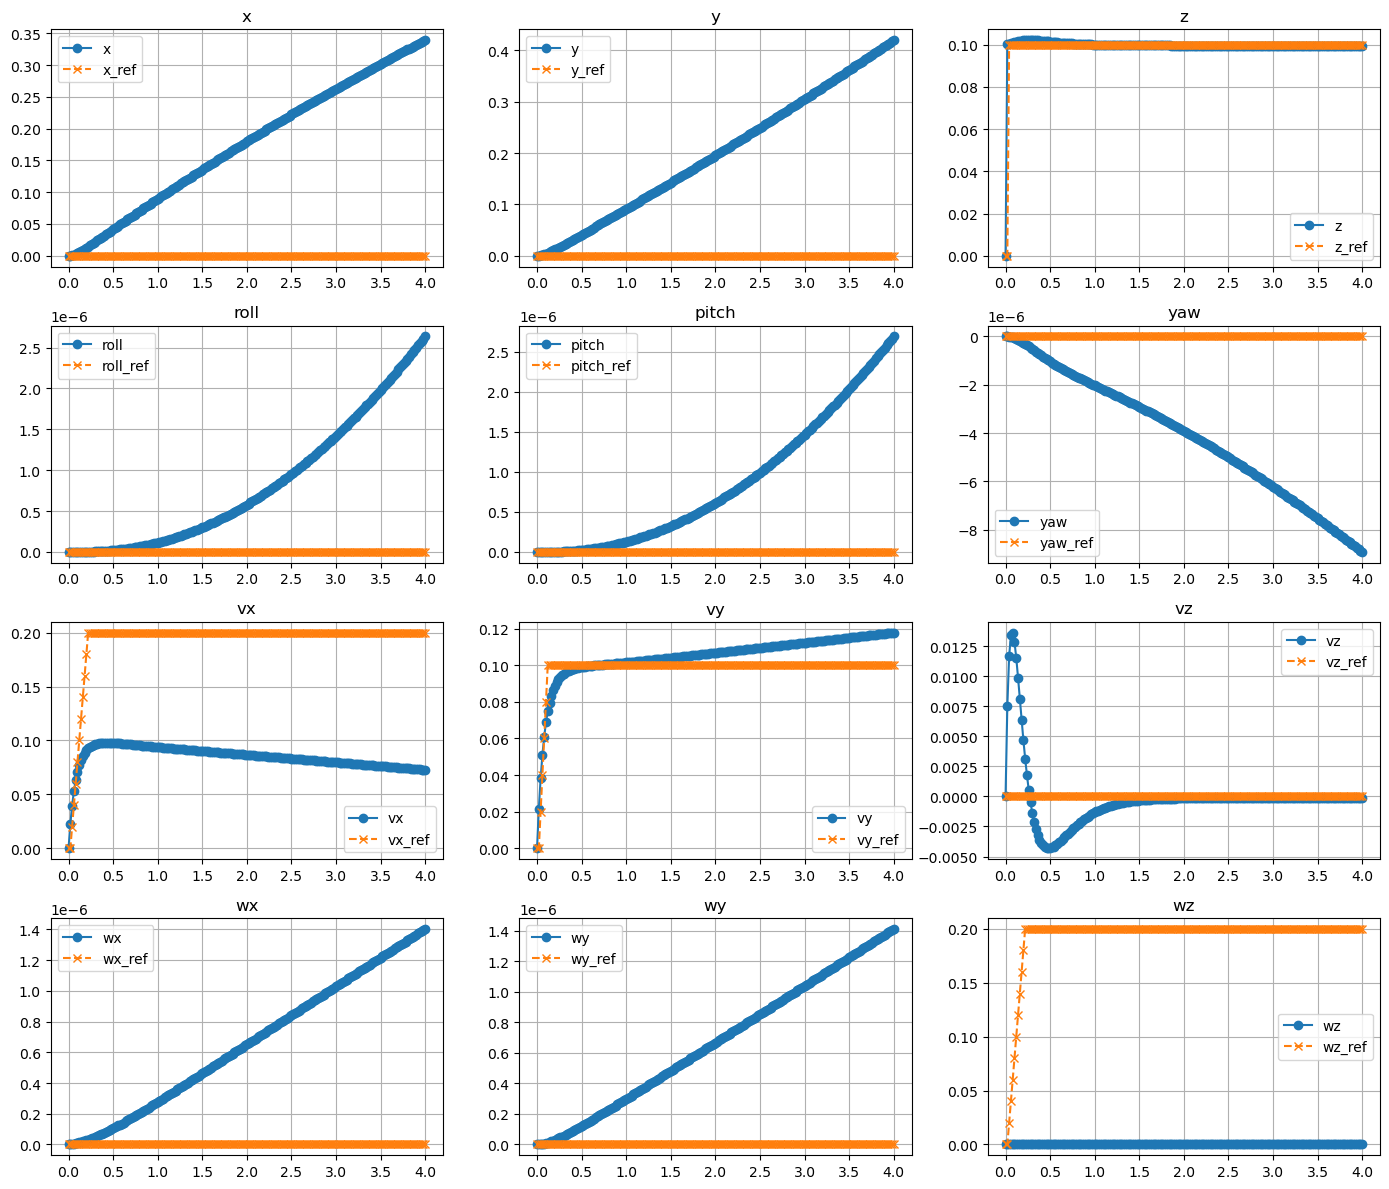

In [9]:
import matplotlib.pyplot as plt
import numpy as np

if 'dt' not in globals():
    dt = 0.02

t_cl = np.arange(p_dec.shape[0]) * dt
ref_pad = np.zeros_like(p_dec)
if 'ref_state_hist' in globals() and len(ref_state_hist) > 0:
    ref_pad = np.vstack([ref_state_hist[0], ref_state_hist])

fig, axes = plt.subplots(4, 3, figsize=(14, 12))
axes = axes.flatten()
labels = ['x','y','z','roll','pitch','yaw','vx','vy','vz','wx','wy','wz']
data = [p_dec[:,0], p_dec[:,1], p_dec[:,2],
         eul_dec[:,0], eul_dec[:,1], eul_dec[:,2],
         v_dec[:,0], v_dec[:,1], v_dec[:,2],
         w_dec[:,0], w_dec[:,1], w_dec[:,2]]
ref_data = [ref_pad[:len(t_cl),0], ref_pad[:len(t_cl),1], ref_pad[:len(t_cl),2],
            ref_pad[:len(t_cl),3], ref_pad[:len(t_cl),4], ref_pad[:len(t_cl),5],
            ref_pad[:len(t_cl),6], ref_pad[:len(t_cl),7], ref_pad[:len(t_cl),8],
            ref_pad[:len(t_cl),9], ref_pad[:len(t_cl),10], ref_pad[:len(t_cl),11]]
for i in range(12):
    axes[i].plot(t_cl, data[i], marker='o', label=labels[i])
    axes[i].plot(t_cl, ref_data[i], '--', marker='x', label=f'{labels[i]}_ref')
    axes[i].set_title(labels[i])
    axes[i].grid(True)
    axes[i].legend()
plt.tight_layout()
plt.show()


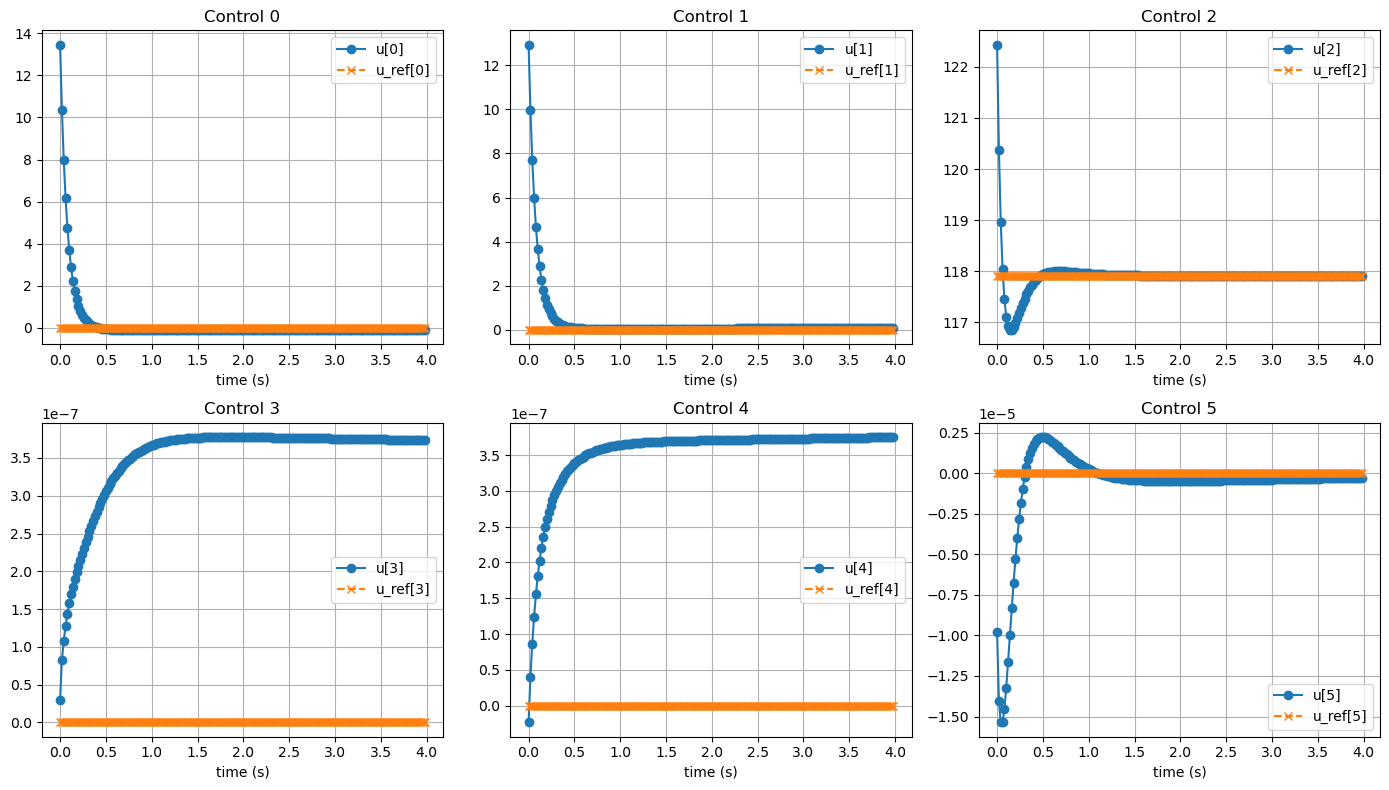

In [10]:
import matplotlib.pyplot as plt
import numpy as np

if 'u_hist' not in globals() or u_hist is None or len(u_hist) == 0:
    u_hist = np.array([np.zeros(B.shape[1]) for _ in range(len(x_phys_hist))])
else:
    u_hist = np.asarray(u_hist, float)
ref_u_pad = np.asarray(ref_control_hist, float) if 'ref_control_hist' in globals() and len(ref_control_hist)>0 else np.zeros_like(u_hist)

t_u = np.arange(u_hist.shape[0]) * dt
cols = u_hist.shape[1]
rows = int(np.ceil(cols / 3))
fig, axes = plt.subplots(rows, 3, figsize=(14, 4*rows))
axes = axes.flatten()
for i in range(cols):
    axes[i].plot(t_u, u_hist[:, i], marker='o', label=f'u[{i}]')
    if ref_u_pad.shape[0] == u_hist.shape[0]:
        axes[i].plot(t_u, ref_u_pad[:, i], '--', marker='x', label=f'u_ref[{i}]')
    axes[i].set_title(f'Control {i}')
    axes[i].set_xlabel('time (s)')
    axes[i].grid(True)
    axes[i].legend()
for j in range(cols, len(axes)):
    axes[j].axis('off')
plt.tight_layout()
plt.show()
